In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
import os
print(os.getcwd())


c:\Users\farha\visualization\02_activities\assignments


In [11]:
df = pd.read_csv(
    r'c:\Users\farha\visualization\02_activities\assignments\SR2025.csv',
    encoding='ISO-8859-1',  # or encoding='latin1'
    on_bad_lines='skip'
)


In [12]:
df.shape
df.head()
df.columns


Index(['Creation Date', 'Status', 'First 3 Chars of Postal Code',
       'Intersection Street 1', 'Intersection Street 2', 'Ward',
       'Service Request Type', 'Division', 'Section'],
      dtype='object')

In [17]:
df['date_received'] = pd.to_datetime(df['Creation Date'], errors='coerce')
df = df.dropna(subset=['date_received'])
df['month'] = df['date_received'].dt.to_period('M')


In [18]:
top_categories = df['Service Request Type'].value_counts().nlargest(10).index
df_top = df[df['Service Request Type'].isin(top_categories)]


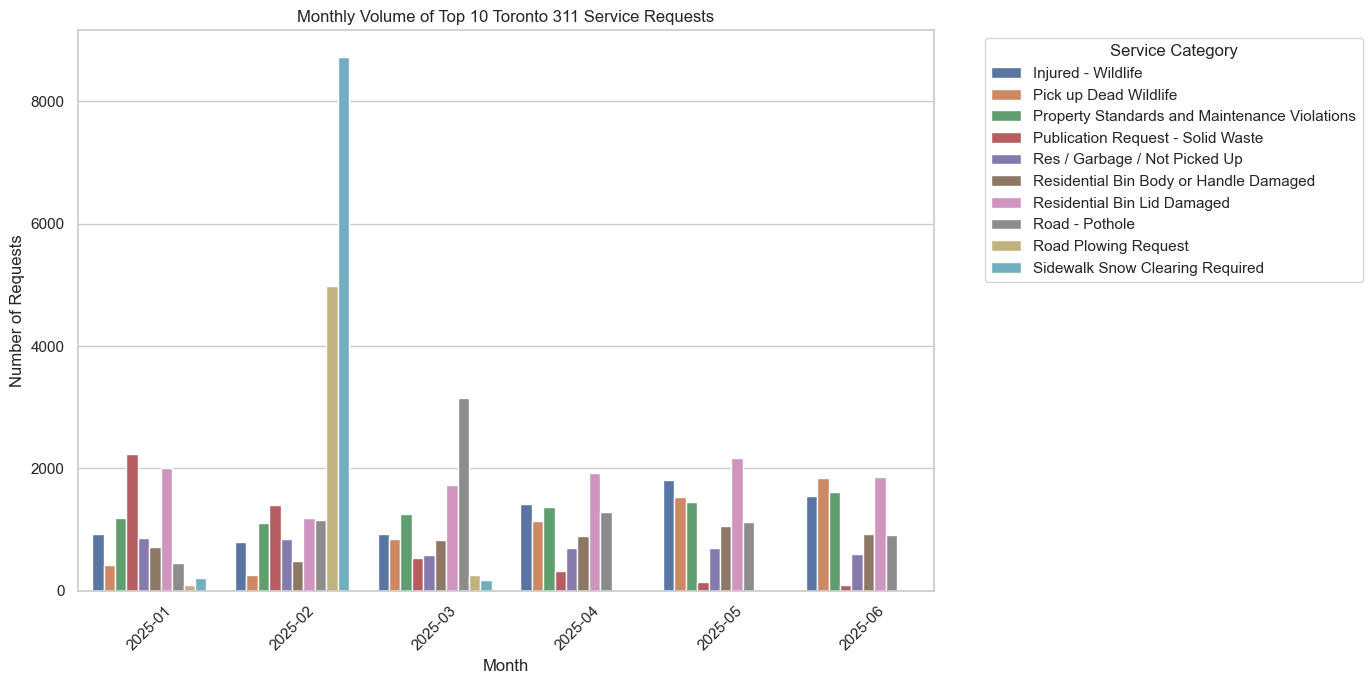

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

monthly_counts = df_top.groupby(['month', 'Service Request Type']).size().reset_index(name='count')
monthly_counts['month'] = monthly_counts['month'].astype(str)

plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

sns.barplot(
    data=monthly_counts,
    x='month',
    y='count',
    hue='Service Request Type'
)

plt.xticks(rotation=45)
plt.title('Monthly Volume of Top 10 Toronto 311 Service Requests')
plt.xlabel('Month')
plt.ylabel('Number of Requests')
plt.legend(title='Service Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
